# EDA VS Data Quality Checks
🧠 The relationship (this is where many people get confused)
1. EDA (Exploratory Data Analysis)
Done once (or occasionally) by a human
Purpose: understand the data
distributions
anomalies
relationships
weird edge cases

👉 EDA answers:

“What can go wrong with this data?”

2. Data Quality Checks
Done automatically in pipelines (every run)
Purpose: enforce rules
no nulls in key columns
no duplicates
valid ranges
referential integrity

👉 Data quality answers:

“Is the data still behaving as expected?”

🔥 The key insight (this is senior-level thinking)

EDA defines the rules → Data Quality enforces them

# THIS CODE SHOULD BE MODIFIED TO READ THE DATA FROM THE DATA BASE NOT FROM THE LOCAL FILE

# The upcoming cells needs to have a comprehensive graphs to show us the distributions of most of the colunms of our data base

TPC-H COMPREHENSIVE EXPLORATORY DATA ANALYSIS
Data path: ../../../data/raw/tables/work_data
Spark version: 3.4.1

📂 LOADING TABLES FROM WORK_DATA STRUCTURE:
----------------------------------------

  📁 Base Layer:
    ✅ lineitem_base_60.parquet :    3,708,231 rows, 16 columns
    ✅ orders_base_60.parquet   :      927,067 rows,  9 columns

  📁 Incremental Batches:

    📦 batch_1:
      📄 year_1995/orders.parquet:       10,290 rows
      📄 year_1995/lineitem.parquet:       41,043 rows
      📄 year_1996/orders.parquet:      195,533 rows
      📄 year_1996/lineitem.parquet:      782,571 rows

    📦 batch_2:
      📄 year_1996/orders.parquet:       40,023 rows
      📄 year_1996/lineitem.parquet:      160,415 rows
      📄 year_1997/orders.parquet:      166,053 rows
      📄 year_1997/lineitem.parquet:      663,767 rows

    📦 batch_3:
      📄 year_1997/orders.parquet:       68,664 rows
      📄 year_1997/lineitem.parquet:      273,492 rows
      📄 year_1998/orders.parquet:      137,645 rows
   

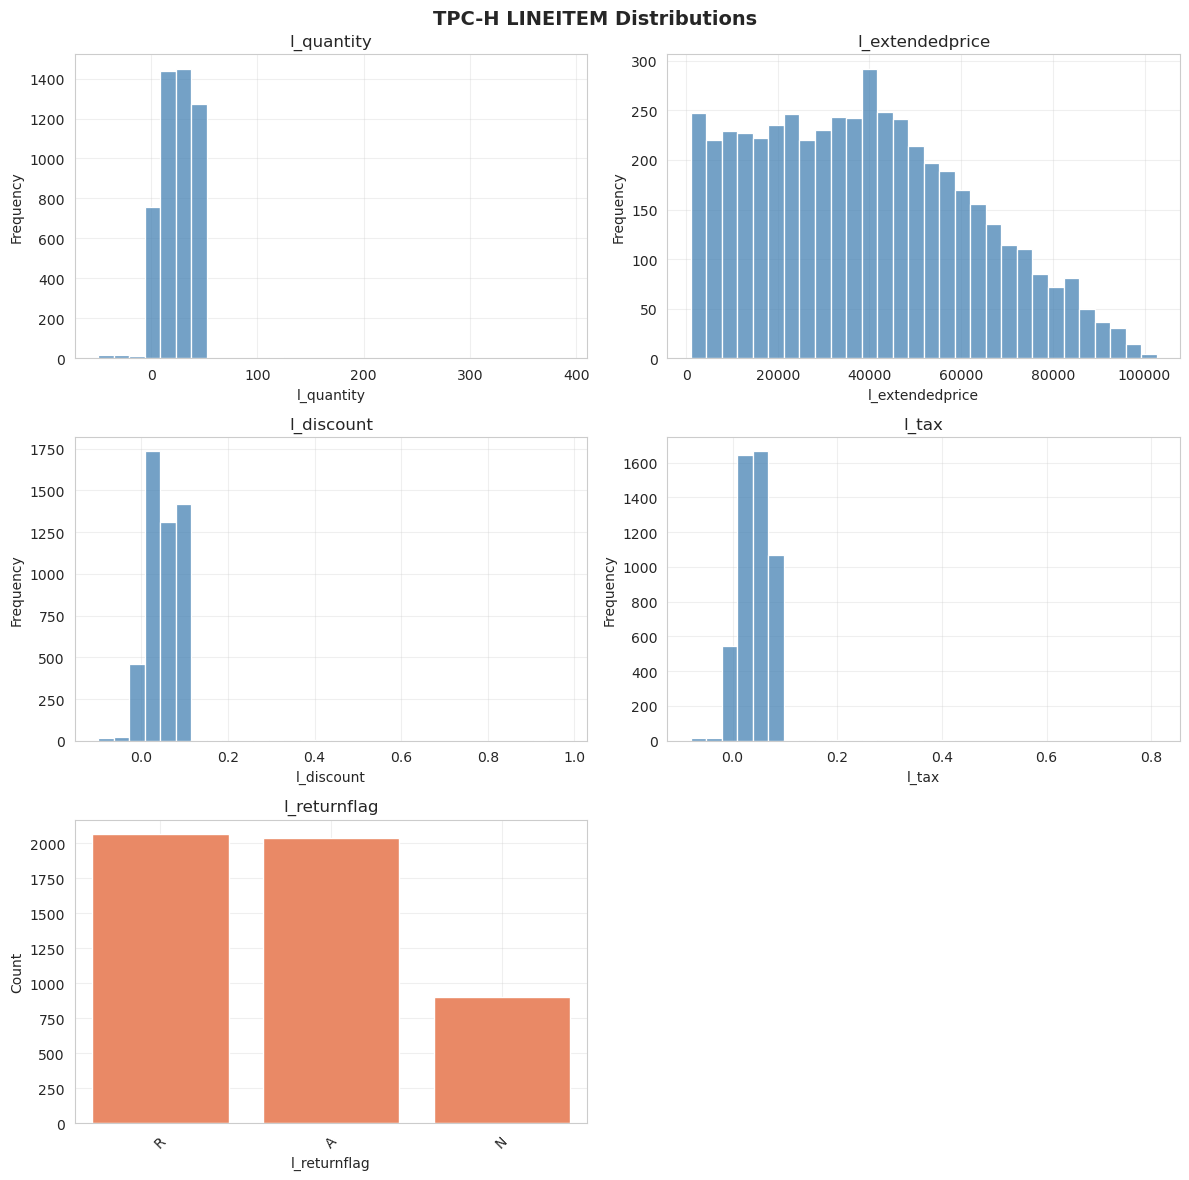


📊 ORDERS - 3 columns


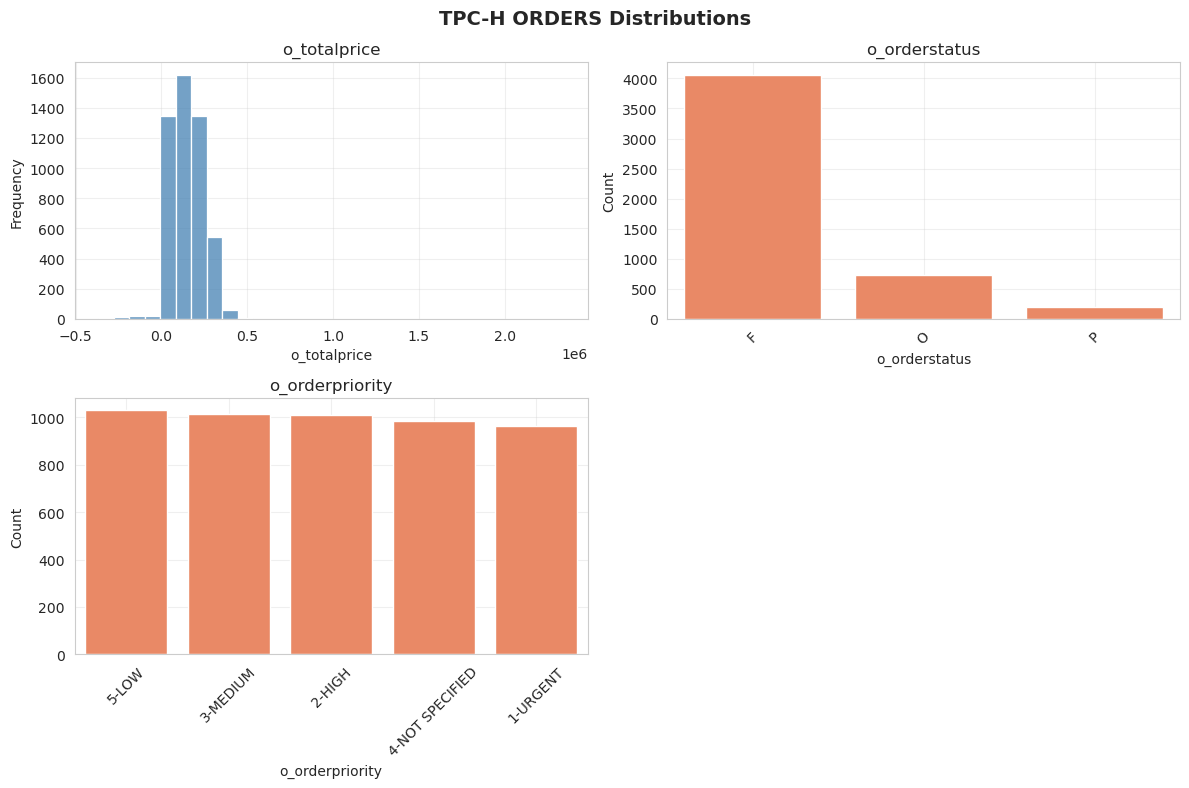


📈 SUMMARY STATISTICS

LINEITEM Table:
----------------------------------------
  Total records: 6,180,592
  Quantity stats: min=-50.00, max=524.90, avg=25.82
  Return flag distribution:
    N: 3,135,087 (50.7%)
    R: 1,522,849 (24.6%)
    A: 1,522,656 (24.6%)
  Discount stats: min=-0.100, max=1.049, avg=0.051

ORDERS Table:
----------------------------------------
  Total records: 1,545,275
  Distinct orders: 1,500,000
  Order status distribution:
    O: 754,216 (48.8%)
    F: 751,338 (48.6%)
    P: 39,721 (2.6%)
  Order price stats:
    Min: $-496167.96
    Max: $4272680.09
    Avg: $153037.36
    StdDev: $121898.18

✅ EDA COMPLETED SUCCESSFULLY!


In [6]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datetime import datetime
import os
import numpy as np

# Initialize Spark with optimized settings for your laptop
spark = SparkSession.builder \
    .appName("TPC-H Comprehensive EDA") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.sql.adaptive.skewJoin.enabled", "true") \
    .config("spark.sql.parquet.compression.codec", "snappy") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.autoBroadcastJoinThreshold", "10485760") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

# Set log level to reduce noise
spark.sparkContext.setLogLevel("WARN")

# Define path to your work_data folder
data_path = "../../../data/raw/tables/work_data"

# Check if the path exists
if not os.path.exists(data_path):
    print(f"❌ Error: Data path not found at {data_path}")
    print("Available directories in ../../../data/raw/tables/:")
    parent_path = "../../../data/raw/tables/"
    if os.path.exists(parent_path):
        for item in os.listdir(parent_path):
            if os.path.isdir(os.path.join(parent_path, item)):
                print(f"  📁 {item}/")
    exit(1)

print("="*80)
print("TPC-H COMPREHENSIVE EXPLORATORY DATA ANALYSIS")
print("="*80)
print(f"Data path: {data_path}")
print(f"Spark version: {spark.version}")
print("="*80)

def load_all_tables_from_curated(spark, data_path):
    """Load all TPC-H tables from work_data folder structure"""
    
    tables = {}
    
    print("\n📂 LOADING TABLES FROM WORK_DATA STRUCTURE:")
    print("-" * 40)
    
    # Track totals
    total_orders = 0
    total_lineitems = 0
    
    # 1. Load base layer
    base_path = os.path.join(data_path, "bases")
    if os.path.exists(base_path):
        print("\n  📁 Base Layer:")
        for file in os.listdir(base_path):
            if file.endswith('.parquet'):
                full_path = os.path.join(base_path, file)
                table_name = 'orders' if 'orders' in file else 'lineitem' if 'lineitem' in file else file.replace('.parquet', '')
                
                try:
                    df = spark.read.parquet(full_path)
                    
                    if table_name not in tables:
                        tables[table_name] = []
                    
                    tables[table_name].append(df)
                    count = df.count()
                    
                    if 'orders' in file:
                        total_orders += count
                    elif 'lineitem' in file:
                        total_lineitems += count
                    
                    print(f"    ✅ {file:25}: {count:12,} rows, {len(df.columns):2} columns")
                except Exception as e:
                    print(f"    ❌ Error loading {file}: {e}")
    else:
        print("\n  ⚠️ Base layer not found (no 'bases' folder)")
    
    # 2. Load incremental batches
    increments_path = os.path.join(data_path, "increments")
    if os.path.exists(increments_path):
        print("\n  📁 Incremental Batches:")
        
        # Find all batch folders
        batch_folders = [d for d in os.listdir(increments_path) 
                        if os.path.isdir(os.path.join(increments_path, d)) and d.startswith('batch_')]
        
        for batch_name in sorted(batch_folders):
            batch_path = os.path.join(increments_path, batch_name)
            
            print(f"\n    📦 {batch_name}:")
            
            # Find all year folders
            year_folders = [d for d in os.listdir(batch_path) 
                           if os.path.isdir(os.path.join(batch_path, d)) and d.startswith('year_')]
            
            for year_dir in sorted(year_folders):
                year_path = os.path.join(batch_path, year_dir)
                
                # Load orders
                orders_file = os.path.join(year_path, "orders.parquet")
                if os.path.exists(orders_file):
                    try:
                        df_orders = spark.read.parquet(orders_file)
                        orders_count = df_orders.count()
                        total_orders += orders_count
                        
                        if 'orders' not in tables:
                            tables['orders'] = []
                        tables['orders'].append(df_orders)
                        
                        print(f"      📄 {year_dir}/orders.parquet: {orders_count:12,} rows")
                    except Exception as e:
                        print(f"      ❌ Error loading {year_dir}/orders.parquet: {e}")
                
                # Load lineitem
                lineitem_file = os.path.join(year_path, "lineitem.parquet")
                if os.path.exists(lineitem_file):
                    try:
                        df_lineitem = spark.read.parquet(lineitem_file)
                        lineitem_count = df_lineitem.count()
                        total_lineitems += lineitem_count
                        
                        if 'lineitem' not in tables:
                            tables['lineitem'] = []
                        tables['lineitem'].append(df_lineitem)
                        
                        print(f"      📄 {year_dir}/lineitem.parquet: {lineitem_count:12,} rows")
                    except Exception as e:
                        print(f"      ❌ Error loading {year_dir}/lineitem.parquet: {e}")
    else:
        print("\n  ⚠️ Incremental batches not found (no 'increments' folder)")
    
    # Combine multiple DataFrames for each table
    combined_tables = {}
    for table_name, df_list in tables.items():
        if len(df_list) == 0:
            continue
        elif len(df_list) == 1:
            combined_tables[table_name] = df_list[0]
        else:
            # Union all DataFrames
            combined = df_list[0]
            for df in df_list[1:]:
                combined = combined.union(df)
            combined_tables[table_name] = combined
        
        # Cache large tables
        if table_name in ['orders', 'lineitem']:
            combined_tables[table_name].cache()
            count = combined_tables[table_name].count()  # Force cache
            print(f"\n  📊 Cached {table_name}: {count:,} rows")
    
    print("\n" + "="*40)
    print("📊 LOADING SUMMARY:")
    print(f"  Total Orders: {total_orders:,}")
    print(f"  Total Lineitems: {total_lineitems:,}")
    if total_orders > 0:
        print(f"  Avg Lineitems per Order: {total_lineitems/total_orders:.2f}")
    
    return combined_tables

# Load all tables from work_data structure
tables = load_all_tables_from_curated(spark, data_path)

if not tables:
    print("\n❌ No tables were loaded! Please check your data structure.")
    exit(1)

def assess_data_quality(tables):
    """Check data quality metrics for each table"""
    
    print("\n🔍 DATA QUALITY ASSESSMENT:")
    print("=" * 80)
    
    for table_name, df in tables.items():
        print(f"\n📊 Table: {table_name.upper()}")
        print("-" * 60)
        
        # Basic stats
        total_rows = df.count()
        print(f"  Total rows: {total_rows:,}")
        
        # Check for nulls in each column
        null_checks = []
        for col_name in df.columns:
            try:
                null_count = df.filter(df[col_name].isNull()).count()
                null_pct = (null_count / total_rows) * 100 if total_rows > 0 else 0
                if null_count > 0:
                    null_checks.append(f"    {col_name}: {null_count:,} nulls ({null_pct:.2f}%)")
            except:
                pass
        
        # Check for duplicates (based on key columns)
        if table_name == 'orders' and 'o_orderkey' in df.columns:
            distinct_count = df.select("o_orderkey").distinct().count()
            if distinct_count != total_rows:
                duplicate_count = total_rows - distinct_count
                print(f"  ⚠️  Duplicate orders: {duplicate_count:,} ({duplicate_count/total_rows*100:.2f}%)")
        
        elif table_name == 'lineitem' and all(c in df.columns for c in ['l_orderkey', 'l_linenumber']):
            distinct_count = df.select("l_orderkey", "l_linenumber").distinct().count()
            if distinct_count != total_rows:
                duplicate_count = total_rows - distinct_count
                print(f"  ⚠️  Duplicate lineitems: {duplicate_count:,} ({duplicate_count/total_rows*100:.2f}%)")
        
        # Print null checks
        if null_checks:
            print("  ⚠️  Null values found:")
            for check in null_checks:
                print(check)
        else:
            print("  ✅ No null values found")
        
        # Column statistics for numeric columns
        print("\n  📈 Numeric Column Statistics:")
        numeric_cols = []
        for col_name in df.columns:
            try:
                if isinstance(df.schema[col_name].dataType, (IntegerType, LongType, DoubleType, FloatType, DecimalType)):
                    numeric_cols.append(col_name)
            except:
                pass
        
        for col_name in numeric_cols[:5]:  # First 5 numeric columns
            try:
                stats = df.agg(
                    min(col_name).alias('min'),
                    max(col_name).alias('max'),
                    avg(col_name).alias('avg')
                ).collect()[0]
                
                if stats['min'] is not None and stats['max'] is not None:
                    print(f"    {col_name}: min={stats['min']:.2f}, max={stats['max']:.2f}, avg={stats['avg']:.2f}")
            except:
                pass
        
        # Special analysis for comment fields
        comment_col = 'o_comment' if table_name == 'orders' else 'l_comment' if table_name == 'lineitem' else None
        if comment_col and comment_col in df.columns:
            print("\n  📝 Comment Field Analysis:")
            
            # Check for special characters
            try:
                special_chars = df.filter(df[comment_col].rlike(".*[@#$%&*!?].*")).count()
                if special_chars > 0:
                    print(f"    ⚠️  Special characters: {special_chars:,} ({special_chars/total_rows*100:.2f}%)")
            except:
                pass
            
            # Check for leading/trailing spaces
            try:
                spaces = df.filter((df[comment_col].like(" %")) | (df[comment_col].like("% "))).count()
                if spaces > 0:
                    print(f"    ⚠️  Leading/trailing spaces: {spaces:,} ({spaces/total_rows*100:.2f}%)")
            except:
                pass
            
            # Show sample
            try:
                sample_comments = df.select(comment_col).filter(
                    (df[comment_col].rlike(".*[@#$%&*!?].*")) |
                    (df[comment_col].like(" %")) |
                    (df[comment_col].like("% "))
                ).limit(3).collect()
                
                if sample_comments:
                    print("    Sample corrupted comments:")
                    for row in sample_comments:
                        comment = str(row[comment_col])[:80]
                        print(f"      - {comment}...")
            except:
                pass

# Run data quality assessment
assess_data_quality(tables)

# Diagnostic information
print("\n" + "="*50)
print("DIAGNOSTIC INFORMATION")
print("="*50)

for table_name, df in tables.items():
    print(f"\n📋 Table: {table_name}")
    print(f"Number of columns: {len(df.columns)}")
    
    # Show column names and their data types
    print("\nColumns and types:")
    for field in df.schema.fields[:10]:  # Show first 10 columns
        print(f"  • {field.name}: {field.dataType}")
    if len(df.schema.fields) > 10:
        print(f"  ... and {len(df.schema.fields) - 10} more columns")
    
    # Show sample of first few rows
    print("\nSample data (first 2 rows):")
    try:
        sample = df.limit(2).toPandas()
        for col in sample.columns[:5]:  # Show first 5 columns
            print(f"  {col}: {sample[col].tolist()}")
    except Exception as e:
        print(f"  Unable to show sample: {e}")
    
    print("-"*40)

def plot_work_data(tables):
    """
    Plot distributions for work_data with proper axes handling
    """
    
    sns.set_style("whitegrid")
    
    # Define important columns for each table
    important_cols = {
        'lineitem': ['l_quantity', 'l_extendedprice', 'l_discount', 'l_tax', 'l_returnflag'],
        'orders': ['o_totalprice', 'o_orderstatus', 'o_orderpriority']
    }
    
    for table_name, columns in important_cols.items():
        if table_name not in tables:
            continue
            
        df = tables[table_name]
        plot_cols = [col for col in columns if col in df.columns]
        
        if not plot_cols:
            continue
            
        print(f"\n📊 {table_name.upper()} - {len(plot_cols)} columns")
        
        # Calculate subplot layout
        n_cols = len(plot_cols)
        n_rows = (n_cols + 1) // 2  # 2 columns per row
        
        # Create figure
        fig = plt.figure(figsize=(12, 4*n_rows))
        fig.suptitle(f'TPC-H {table_name.upper()} Distributions', fontsize=14, fontweight='bold')
        
        # Create subplots
        for idx, column in enumerate(plot_cols):
            ax = plt.subplot(n_rows, 2, idx + 1)
            
            try:
                # Sample data (limit to 5000 rows for performance)
                sample = df.select(column).limit(5000).toPandas().dropna()
                
                if len(sample) == 0:
                    ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
                    ax.set_title(column)
                    continue
                
                # Try to convert to numeric for histogram
                try:
                    numeric_vals = pd.to_numeric(sample[column], errors='coerce').dropna()
                    if len(numeric_vals) > 0 and numeric_vals.dtype in ['int64', 'float64']:
                        # Numeric column - histogram
                        sns.histplot(x=numeric_vals.values, bins=30, color='steelblue', ax=ax)
                        ax.set_xlabel(column)
                        ax.set_ylabel('Frequency')
                    else:
                        # Categorical column - bar chart
                        val_counts = sample[column].astype(str).value_counts().head(10)
                        sns.barplot(x=val_counts.index, y=val_counts.values, color='coral', ax=ax)
                        ax.set_xlabel(column)
                        ax.set_ylabel('Count')
                        ax.tick_params(axis='x', rotation=45)
                except:
                    # Fallback to categorical
                    val_counts = sample[column].astype(str).value_counts().head(10)
                    sns.barplot(x=val_counts.index, y=val_counts.values, color='coral', ax=ax)
                    ax.set_xlabel(column)
                    ax.set_ylabel('Count')
                    ax.tick_params(axis='x', rotation=45)
                
                ax.set_title(column)
                ax.grid(True, alpha=0.3)
                
            except Exception as e:
                ax.text(0.5, 0.5, f'Error: {str(e)[:50]}', ha='center', va='center', transform=ax.transAxes)
                ax.set_title(column)
        
        plt.tight_layout()
        plt.show()

# Run the plotting function
print("\n" + "="*80)
print("📊 GENERATING DISTRIBUTION PLOTS")
print("="*80)

plot_work_data(tables)

# Additional summary statistics
print("\n" + "="*80)
print("📈 SUMMARY STATISTICS")
print("="*80)

for table_name, df in tables.items():
    print(f"\n{table_name.upper()} Table:")
    print("-" * 40)
    
    total_rows = df.count()
    print(f"  Total records: {total_rows:,}")
    
    # Distinct values for key columns
    if table_name == 'orders' and 'o_orderkey' in df.columns:
        distinct_orders = df.select("o_orderkey").distinct().count()
        print(f"  Distinct orders: {distinct_orders:,}")
        
        # Order status distribution
        status_dist = df.groupBy("o_orderstatus").count().orderBy("count", ascending=False).collect()
        if status_dist:
            print(f"  Order status distribution:")
            for row in status_dist:
                print(f"    {row['o_orderstatus']}: {row['count']:,} ({row['count']/total_rows*100:.1f}%)")
        
        # Price statistics
        if 'o_totalprice' in df.columns:
            price_stats = df.agg(
                min("o_totalprice").alias("min"),
                max("o_totalprice").alias("max"),
                avg("o_totalprice").alias("avg"),
                stddev("o_totalprice").alias("stddev")
            ).collect()[0]
            if price_stats['min'] is not None:
                print(f"  Order price stats:")
                print(f"    Min: ${price_stats['min']:.2f}")
                print(f"    Max: ${price_stats['max']:.2f}")
                print(f"    Avg: ${price_stats['avg']:.2f}")
                print(f"    StdDev: ${price_stats['stddev']:.2f}")
    
    elif table_name == 'lineitem':
        # Lineitem statistics
        if 'l_quantity' in df.columns:
            qty_stats = df.agg(
                min("l_quantity").alias("min"),
                max("l_quantity").alias("max"),
                avg("l_quantity").alias("avg")
            ).collect()[0]
            if qty_stats['min'] is not None:
                print(f"  Quantity stats: min={qty_stats['min']:.2f}, max={qty_stats['max']:.2f}, avg={qty_stats['avg']:.2f}")
        
        # Return flag distribution
        if 'l_returnflag' in df.columns:
            return_dist = df.groupBy("l_returnflag").count().orderBy("count", ascending=False).collect()
            if return_dist:
                print(f"  Return flag distribution:")
                for row in return_dist:
                    print(f"    {row['l_returnflag']}: {row['count']:,} ({row['count']/total_rows*100:.1f}%)")
        
        # Discount stats
        if 'l_discount' in df.columns:
            discount_stats = df.agg(
                min("l_discount").alias("min"),
                max("l_discount").alias("max"),
                avg("l_discount").alias("avg")
            ).collect()[0]
            if discount_stats['min'] is not None:
                print(f"  Discount stats: min={discount_stats['min']:.3f}, max={discount_stats['max']:.3f}, avg={discount_stats['avg']:.3f}")

print("\n" + "="*80)
print("✅ EDA COMPLETED SUCCESSFULLY!")
print("="*80)

In [5]:
# NEW EDA (needs modification)

In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import os

# Initialize Spark
spark = SparkSession.builder \
    .appName("EDA") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

def find_work_data_files(data_path):
    """Find all parquet files in work_data structure"""
    files_to_analyze = []
    
    # 1. Check base layer
    base_path = os.path.join(data_path, "bases")
    if os.path.exists(base_path):
        for file in os.listdir(base_path):
            if file.endswith('.parquet'):
                files_to_analyze.append({
                    'path': os.path.join(base_path, file),
                    'name': f"base_{file.replace('.parquet', '')}"
                })
    
    # 2. Check incremental batches
    increments_path = os.path.join(data_path, "increments")
    if os.path.exists(increments_path):
        for batch in sorted(os.listdir(increments_path)):
            batch_path = os.path.join(increments_path, batch)
            if os.path.isdir(batch_path):
                for year_dir in sorted(os.listdir(batch_path)):
                    if year_dir.startswith("year_"):
                        year_path = os.path.join(batch_path, year_dir)
                        # Check for orders and lineitem
                        orders_file = os.path.join(year_path, "orders.parquet")
                        if os.path.exists(orders_file):
                            files_to_analyze.append({
                                'path': orders_file,
                                'name': f"{batch}_{year_dir}_orders"
                            })
                        
                        lineitem_file = os.path.join(year_path, "lineitem.parquet")
                        if os.path.exists(lineitem_file):
                            files_to_analyze.append({
                                'path': lineitem_file,
                                'name': f"{batch}_{year_dir}_lineitem"
                            })
    
    return files_to_analyze

def perform_simple_eda(file_path, table_name):
    """Perform simple EDA on a parquet file"""
    
    print(f"\n{'='*80}")
    print(f"EDA Report for: {table_name}")
    print(f"{'='*80}")
    
    # Read the parquet file
    df = spark.read.parquet(file_path)
    total_records = df.count()
    
    # 1. Basic Information
    print(f"\n1. BASIC INFORMATION:")
    print(f"   - Total Records: {total_records:,}")
    print(f"   - Total Columns: {len(df.columns)}")
    print(f"   - Column Names: {', '.join(df.columns)}")
    
    # 2. Schema Information
    print(f"\n2. SCHEMA:")
    for field in df.schema.fields:
        print(f"   - {field.name}: {field.dataType}")
    
    # 3. NULL Values Analysis
    print(f"\n3. NULL VALUES ANALYSIS:")
    null_counts = []
    for col_name in df.columns:
        null_count = df.filter(df[col_name].isNull()).count()
        null_pct = (null_count / total_records) * 100 if total_records > 0 else 0
        print(f"   - {col_name}: {null_count:,} NULLs ({null_pct:.2f}%)")
        null_counts.append((col_name, null_count, null_pct))
    
    # 4. Duplicate Records Analysis
    print(f"\n4. DUPLICATE RECORDS:")
    
    # Check for exact duplicate rows
    duplicate_rows = total_records - df.dropDuplicates().count()
    print(f"   - Exact duplicate rows: {duplicate_rows:,}")
    
    # Check for duplicate keys (columns with 'key' in name)
    key_columns = [col for col in df.columns if 'key' in col.lower()]
    if key_columns:
        duplicate_keys = df.groupBy(key_columns).count().filter(col("count") > 1).count()
        print(f"   - Duplicate key groups (keys: {key_columns}): {duplicate_keys}")
        
        if duplicate_keys > 0:
            # Show sample of duplicate keys
            sample_duplicates = df.groupBy(key_columns).count() \
                                 .filter(col("count") > 1) \
                                 .orderBy(desc("count")) \
                                 .limit(3).collect()
            print(f"   - Sample duplicate keys (showing first key column only):")
            for row in sample_duplicates:
                key_value = row[0] if key_columns else "N/A"
                count_val = row['count']
                print(f"     * Key value: {key_value} appears {count_val} times")
    
    # 5. String Columns Analysis
    print(f"\n5. STRING COLUMNS ANALYSIS:")
    string_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType)]
    
    if string_cols:
        for col_name in string_cols:
            print(f"\n   Column: {col_name}")
            
            # Get basic stats for string column
            non_null_count = df.filter(df[col_name].isNotNull()).count()
            
            # Check for empty strings
            empty_count = df.filter(df[col_name] == "").count()
            
            # Check for leading spaces
            leading_spaces = df.filter(df[col_name].like(" %")).count()
            
            # Check for trailing spaces
            trailing_spaces = df.filter(df[col_name].like("% ")).count()
            
            # Check for special characters (common ones)
            special_chars_pattern = ".*[@#$%&*!?].*"
            special_chars_count = df.filter(df[col_name].rlike(special_chars_pattern)).count()
            
            # Get distinct count
            distinct_count = df.select(df[col_name]).distinct().count()
            
            print(f"     - Non-null count: {non_null_count:,} ({non_null_count/total_records*100:.2f}%)")
            print(f"     - Empty strings: {empty_count:,}")
            print(f"     - Leading spaces: {leading_spaces:,}")
            print(f"     - Trailing spaces: {trailing_spaces:,}")
            print(f"     - Contains special characters (@#$%&*!?): {special_chars_count:,}")
            print(f"     - Distinct values: {distinct_count:,}")
            
            # Show sample values
            sample_values = df.select(df[col_name]).limit(5).collect()
            print(f"     - Sample values: {[row[col_name] for row in sample_values]}")
    else:
        print("   No string columns found")
    
    # 6. Numeric Columns Analysis
    print(f"\n6. NUMERIC COLUMNS ANALYSIS:")
    numeric_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, (IntegerType, LongType, FloatType, DoubleType, DecimalType))]
    
    if numeric_cols:
        for col_name in numeric_cols:
            print(f"\n   Column: {col_name}")
            
            # Get basic statistics
            stats = df.select(
                count(df[col_name]).alias("count"),
                min(df[col_name]).alias("min"),
                max(df[col_name]).alias("max"),
                mean(df[col_name]).alias("mean"),
                stddev(df[col_name]).alias("stddev")
            ).collect()[0]
            
            # Format the values for display
            min_val = stats['min']
            max_val = stats['max']
            mean_val = stats['mean']
            stddev_val = stats['stddev']
            
            # Format numeric values with proper handling
            min_display = f"{min_val:.2f}" if min_val is not None else "NULL"
            max_display = f"{max_val:.2f}" if max_val is not None else "NULL"
            mean_display = f"{mean_val:.2f}" if mean_val is not None else "NULL"
            stddev_display = f"{stddev_val:.2f}" if stddev_val is not None else "NULL"
            
            # Check for outliers (using IQR method)
            quantiles = df.approxQuantile(col_name, [0.25, 0.75], 0.01)
            if len(quantiles) == 2 and quantiles[0] is not None and quantiles[1] is not None:
                q1, q3 = quantiles[0], quantiles[1]
                iqr = q3 - q1
                lower_bound = q1 - 1.5 * iqr
                upper_bound = q3 + 1.5 * iqr
                outliers = df.filter((df[col_name] < lower_bound) | (df[col_name] > upper_bound)).count()
            else:
                outliers = 0
            
            print(f"     - Non-null count: {stats['count']:,}")
            print(f"     - Min: {min_display}")
            print(f"     - Max: {max_display}")
            print(f"     - Mean: {mean_display}")
            print(f"     - StdDev: {stddev_display}")
            print(f"     - Outliers (IQR method): {outliers:,}")
    else:
        print("   No numeric columns found")
    
    # 7. Date Columns Analysis
    print(f"\n7. DATE COLUMNS ANALYSIS:")
    date_cols = [f.name for f in df.schema.fields if 'date' in f.name.lower() or isinstance(f.dataType, (DateType, TimestampType))]
    
    if date_cols:
        for col_name in date_cols:
            print(f"\n   Column: {col_name}")
            
            # Get date range
            date_range = df.select(
                min(df[col_name]).alias("min_date"),
                max(df[col_name]).alias("max_date")
            ).collect()[0]
            
            min_date = date_range['min_date']
            max_date = date_range['max_date']
            
            print(f"     - Min date: {min_date if min_date else 'NULL'}")
            print(f"     - Max date: {max_date if max_date else 'NULL'}")
            
            # Check for invalid dates (if column is string type with dates)
            if isinstance(df.schema[col_name].dataType, StringType):
                invalid_dates = df.filter(~df[col_name].rlike(r'^\d{4}-\d{2}-\d{2}$')).count()
                print(f"     - Invalid date formats: {invalid_dates:,}")
    else:
        print("   No date columns found")
    
    # 8. Summary
    print(f"\n8. SUMMARY:")
    print(f"   Total Issues Detected:")
    
    # Count total nulls (manual sum to avoid conflict)
    total_nulls = 0
    for nc in null_counts:
        total_nulls += nc[1]
    print(f"   - Total NULL values: {total_nulls:,}")
    
    # Count potential quality issues (manual sum to avoid conflict)
    quality_issues = 0
    for col_name in string_cols:
        issues = df.filter(
            (df[col_name].like(" %")) | 
            (df[col_name].like("% ")) |
            (df[col_name].rlike(".*[@#$%&*!?].*"))
        ).count()
        quality_issues += issues
    print(f"   - String formatting issues (spaces/special chars): {quality_issues:,}")
    
    if duplicate_rows > 0:
        print(f"   - Duplicate rows: {duplicate_rows:,}")
    
    print(f"\n{'='*80}\n")
    
    return df

def main():
    """Main function to perform EDA on work_data structure"""
    
    # Define path to work_data
    data_path = "../../../data/raw/tables/work_data"
    
    # Check if path exists
    if not os.path.exists(data_path):
        print(f"Error: Path {data_path} does not exist!")
        print("Available directories in ../../../data/raw/tables/:")
        parent_path = "../../../data/raw/tables/"
        if os.path.exists(parent_path):
            for item in os.listdir(parent_path):
                if os.path.isdir(os.path.join(parent_path, item)):
                    print(f"  📁 {item}/")
        return
    
    print("="*80)
    print("EDA FOR WORK_DATA STRUCTURE")
    print("="*80)
    print(f"Data path: {data_path}")
    
    # Find all files to analyze
    files_to_analyze = find_work_data_files(data_path)
    
    if not files_to_analyze:
        print("No parquet files found in work_data structure!")
        return
    
    print(f"\nFound {len(files_to_analyze)} files to analyze:")
    for f in files_to_analyze:
        print(f"  - {f['name']}")
    
    # Dictionary to store dataframes
    dataframes = {}
    
    # Perform EDA for each file
    for file_info in files_to_analyze:
        print(f"\n📊 Analyzing {file_info['name']}...")
        try:
            df = perform_simple_eda(file_info['path'], file_info['name'])
            dataframes[file_info['name']] = df
        except Exception as e:
            print(f"   ❌ Error analyzing {file_info['name']}: {str(e)}")
    
    # Print summary of all analyzed files
    print("\n" + "="*80)
    print("EDA SUMMARY")
    print("="*80)
    print(f"Total files analyzed: {len(dataframes)}")
    print(f"Files: {', '.join(dataframes.keys())}")
    
    print("\n✅ EDA completed successfully!")

# Run the EDA
if __name__ == "__main__":
    main()

EDA FOR WORK_DATA STRUCTURE
Data path: ../../../data/raw/tables/work_data

Found 14 files to analyze:
  - base_lineitem_base_60
  - base_orders_base_60
  - batch_1_year_1995_orders
  - batch_1_year_1995_lineitem
  - batch_1_year_1996_orders
  - batch_1_year_1996_lineitem
  - batch_2_year_1996_orders
  - batch_2_year_1996_lineitem
  - batch_2_year_1997_orders
  - batch_2_year_1997_lineitem
  - batch_3_year_1997_orders
  - batch_3_year_1997_lineitem
  - batch_3_year_1998_orders
  - batch_3_year_1998_lineitem

📊 Analyzing base_lineitem_base_60...

EDA Report for: base_lineitem_base_60

1. BASIC INFORMATION:
   - Total Records: 3,708,231
   - Total Columns: 16
   - Column Names: l_orderkey, l_partkey, l_suppkey, l_linenumber, l_quantity, l_extendedprice, l_discount, l_tax, l_returnflag, l_linestatus, l_shipdate, l_commitdate, l_receiptdate, l_shipinstruct, l_shipmode, l_comment

2. SCHEMA:
   - l_orderkey: LongType()
   - l_partkey: LongType()
   - l_suppkey: LongType()
   - l_linenumber: 

# Complex EDA that needs lots of compute
# Dont RUN DONT RUN DONT RUN

In [ ]:
# ─── Spark Session ─────────────────────────────────────────────────────────
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql.window import Window
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np
# Instead of: from pyspark.sql.functions import *
# Use specific imports:
# from pyspark.sql.functions import col, count, when, rand, lit, trim, length, current_date, datediff, abs, mean, stddev, max, min, avg, sum, desc, upper, lower, rlike, regexp_extract
import builtins
python_round = builtins.round

# Then use python_round() wherever you need Python's rounding




# Stop the current Spark session
spark.stop()

# Recreate the Spark session with better memory configuration
spark = (
    SparkSession.builder
    .appName('TPC-H_EDA_Enhanced')
    .config('spark.sql.adaptive.enabled', 'true')
    .config('spark.sql.adaptive.coalescePartitions.enabled', 'true')
    .config('spark.sql.adaptive.skewJoin.enabled', 'true')
    .config('spark.sql.parquet.compression.codec', 'snappy')
    .config('spark.sql.inMemoryColumnarStorage.compressed', 'true')
    .config('spark.sql.autoBroadcastJoinThreshold', '10485760')
    .config('spark.sql.shuffle.partitions', '200')
    # Add memory configurations
    .config('spark.driver.memory', '4g')
    .config('spark.executor.memory', '4g')
    .config('spark.memory.offHeap.enabled', 'true')
    .config('spark.memory.offHeap.size', '2g')
    .config('spark.sql.adaptive.coalescePartitions.parallelismFirst', 'true')
    .config('spark.sql.adaptive.coalescePartitions.minPartitionNum', '1')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')

# ─── Config ────────────────────────────────────────────────────────────────
DATA_PATH   = '/home/jovyan/data/raw/tables/work_data'
SAMPLE_SIZE = 5_000

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'figure.facecolor': 'white'})

print(f'Spark version : {spark.version}')
print(f'Data path     : {DATA_PATH}')
print(f'Path exists   : {os.path.exists(DATA_PATH)}')

# ─── NEW: Per-file analysis tracking ──────────────────────────────────────
per_file_analysis = {}  # Store per-file results for granular analysis

def find_work_data_files(data_path):
    """Find all parquet files in work_data structure for per-file analysis"""
    files_to_analyze = []
    
    # 1. Check base layer
    base_path = os.path.join(data_path, "bases")
    if os.path.exists(base_path):
        for file in os.listdir(base_path):
            if file.endswith('.parquet'):
                files_to_analyze.append({
                    'path': os.path.join(base_path, file),
                    'name': f"base_{file.replace('.parquet', '')}",
                    'layer': 'base',
                    'batch': None,
                    'year': None
                })
    
    # 2. Check incremental batches
    increments_path = os.path.join(data_path, "increments")
    if os.path.exists(increments_path):
        for batch in sorted(os.listdir(increments_path)):
            batch_path = os.path.join(increments_path, batch)
            if os.path.isdir(batch_path):
                for year_dir in sorted(os.listdir(batch_path)):
                    if year_dir.startswith("year_"):
                        year_path = os.path.join(batch_path, year_dir)
                        # Check for orders and lineitem
                        orders_file = os.path.join(year_path, "orders.parquet")
                        if os.path.exists(orders_file):
                            files_to_analyze.append({
                                'path': orders_file,
                                'name': f"{batch}_{year_dir}_orders",
                                'layer': 'increment',
                                'batch': batch,
                                'year': year_dir,
                                'table': 'orders'
                            })
                        
                        lineitem_file = os.path.join(year_path, "lineitem.parquet")
                        if os.path.exists(lineitem_file):
                            files_to_analyze.append({
                                'path': lineitem_file,
                                'name': f"{batch}_{year_dir}_lineitem",
                                'layer': 'increment',
                                'batch': batch,
                                'year': year_dir,
                                'table': 'lineitem'
                            })
    
    return files_to_analyze

## 1. Data Loading (Enhanced with per-file tracking)
def load_tables(spark, data_path, enable_per_file=False):
    """
    Load all TPC-H tables from work_data folder.
    Now with optional per-file analysis tracking.
    """
    if not os.path.exists(data_path):
        raise FileNotFoundError(f'Data path not found: {data_path}')

    accumulator = {}
    per_file_dfs = {} if enable_per_file else None

    # ── Base layer ────────────────────────────────────────────────────────
    base_path = os.path.join(data_path, 'bases')
    if os.path.exists(base_path):
        for fname in sorted(os.listdir(base_path)):
            if not fname.endswith('.parquet'):
                continue
            table = (
                'orders'   if 'orders'   in fname else
                'lineitem' if 'lineitem' in fname else
                fname.replace('.parquet', '')
            )
            df = spark.read.parquet(os.path.join(base_path, fname))
            accumulator.setdefault(table, []).append(df)
            if enable_per_file:
                per_file_dfs[f"base_{table}"] = df
            print(f'  [base]  {fname:<30} {df.count():>12,} rows')

    # ── Incremental batches ───────────────────────────────────────────────
    inc_path = os.path.join(data_path, 'increments')
    if os.path.exists(inc_path):
        for batch in sorted(os.listdir(inc_path)):
            batch_path = os.path.join(inc_path, batch)
            if not os.path.isdir(batch_path):
                continue
            for year_dir in sorted(os.listdir(batch_path)):
                year_path = os.path.join(batch_path, year_dir)
                if not os.path.isdir(year_path):
                    continue
                for table, fname in [('orders', 'orders.parquet'),
                                     ('lineitem', 'lineitem.parquet')]:
                    fpath = os.path.join(year_path, fname)
                    if os.path.exists(fpath):
                        df = spark.read.parquet(fpath)
                        accumulator.setdefault(table, []).append(df)
                        if enable_per_file:
                            per_file_name = f"{batch}_{year_dir}_{table}"
                            per_file_dfs[per_file_name] = df
                        print(f'  [{batch}/{year_dir}]  {fname:<20} {df.count():>12,} rows')

    # ── Union + cache ─────────────────────────────────────────────────────
    tables = {}
    for name, frames in accumulator.items():
        combined = frames[0]
        for f in frames[1:]:
            combined = combined.union(f)
        if name in ('orders', 'lineitem'):
            combined = combined.cache()
            combined.count()   # force materialisation
        tables[name] = combined

    print('\n' + '─' * 50)
    print('  Loading Summary:')
    for name, df in tables.items():
        print(f'  {name:<12} {df.count():>12,} rows  {len(df.columns)} cols')

    if enable_per_file:
        return tables, per_file_dfs
    return tables


print('=' * 60)
print('LOADING TPC-H TABLES')
print('=' * 60)
tables = load_tables(spark, DATA_PATH)

# NEW: Also load per-file data for granular analysis
print('\n' + '=' * 60)
print('LOADING PER-FILE DATA FOR GRANULAR ANALYSIS')
print('=' * 60)
tables, per_file_tables = load_tables(spark, DATA_PATH, enable_per_file=True)

# NEW: Function to detect outliers using IQR (from old code)
def detect_outliers_iqr(df, column):
    """Detect statistical outliers using IQR method (approx for performance)"""
    try:
        # Use approxQuantile for performance on large datasets
        quantiles = df.approxQuantile(column, [0.25, 0.75], 0.01)
        if len(quantiles) == 2 and quantiles[0] is not None and quantiles[1] is not None:
            q1, q3 = quantiles[0], quantiles[1]
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            outliers = df.filter(
                (col(column).isNotNull()) & 
                ((col(column) < lower_bound) | (col(column) > upper_bound))
            ).count()
            return outliers, lower_bound, upper_bound
    except Exception as e:
        pass
    return 0, None, None

# NEW: Function to validate date format for string columns
def validate_date_format(df, column, expected_format=r'^\d{4}-\d{2}-\d{2}$'):
    """Validate date format for string columns"""
    if isinstance(df.schema[column].dataType, StringType) and 'date' in column.lower():
        invalid = df.filter(
            col(column).isNotNull() & 
            (~col(column).rlike(expected_format))
        ).count()
        return invalid
    return 0

# NEW: Function to show sample values for a column
def show_column_samples(df, column, limit=5):
    """Show sample values for a column"""
    try:
        samples = df.select(column).limit(limit).collect()
        return [row[column] for row in samples]
    except:
        return []

# NEW: Function for Z-score outlier detection
def detect_outliers_zscore(df, column, threshold=3):
    """Detect outliers using Z-score method"""
    try:
        stats = df.select(mean(col(column)), stddev(col(column))).collect()
        mean_val, std_val = stats[0][0], stats[0][1]
        
        if std_val and std_val > 0:
            outliers = df.filter(
                col(column).isNotNull() & 
                (abs(col(column) - mean_val) > threshold * std_val)
            ).count()
            return outliers, mean_val, std_val
    except:
        pass
    return 0, None, None

# NEW: Function to calculate data freshness
def calculate_data_freshness(df, date_column):
    """Calculate how many days old the latest data is"""
    try:
        max_date = df.agg(max(date_column)).collect()[0][0]
        if max_date:
            days_lag = (current_date() - max_date).days
            return days_lag, max_date
    except:
        pass
    return None, None

# NEW: Function to detect encoding issues
def detect_encoding_issues(df, column):
    """Detect mojibake or encoding corruption"""
    try:
        # Look for Unicode replacement character or common encoding artifacts
        issues = df.filter(
            col(column).rlike(r'\ufffd') |  # Unicode replacement char
            col(column).rlike(r'Ã') |       # Common UTF-8 mojibake
            col(column).rlike(r'â€™')       # Smart quote mojibake
        ).count()
        return issues
    except:
        pass
    return 0

## 2. Schema & Basic Info
for name, df in tables.items():
    print(f'\n{"=" * 55}')
    print(f'  TABLE: {name.upper()}')
    print(f'{"=" * 55}')
    print(f'  Rows   : {df.count():,}')
    print(f'  Columns: {len(df.columns)}')
    print('  Schema :')
    for field in df.schema.fields:
        print(f'    {field.name:<25} {str(field.dataType)}')

## 3. Null & Duplicate Analysis (Enhanced with IQR and empty string detection)
PRIMARY_KEYS = {
    'orders'  : ['o_orderkey'],
    'lineitem': ['l_orderkey', 'l_linenumber'],
    'customer': ['c_custkey'],
    'part'    : ['p_partkey'],
    'supplier': ['s_suppkey'],
    'partsupp': ['ps_partkey', 'ps_suppkey'],
    'nation'  : ['n_nationkey'],
    'region'  : ['r_regionkey'],
}

# Track all issues
all_issues = {
    'nulls': [],
    'duplicates': [],
    'numeric_range': [],
    'case_inconsistency': [],
    'string_pattern': [],
    'referential_integrity': [],
    'date_logic': [],
    'outliers': [],  # NEW: Track statistical outliers
    'business_logic': [],  # NEW: Track business logic violations
    'data_freshness': [],  # NEW: Track data freshness metrics
    'encoding_issues': [],  # NEW: Track encoding issues
    'volume_anomalies': []  # NEW: Track volume anomalies
}

for name, df in tables.items():
    total = df.count()
    print(f'\n  {name.upper()}  ({total:,} rows)')
    print('  ' + '─' * 55)

    # Null check - Enhanced with column type tracking and empty string detection
    any_null = False
    for c in df.columns:
        n = df.filter(col(c).isNull()).count()
        pct = n / total * 100 if total else 0
        
        # NEW: Check for empty strings (not just NULLs)
        empty_count = 0
        if isinstance(df.schema[c].dataType, StringType):
            empty_count = df.filter((col(c) == "") & col(c).isNotNull()).count()
            if empty_count > 0:
                print(f'    WARN  {c:<28} empty strings: {empty_count:>8,} ({empty_count/total*100:.2f}%)')
                all_issues['string_pattern'].append({
                    'table': name,
                    'column': c,
                    'issue': 'empty_strings',
                    'count': empty_count,
                    'percentage': round(empty_count/total*100, 2)
                })
        
        if n > 0:
            # Get column type for better reporting
            col_type = [f.dataType for f in df.schema.fields if f.name == c][0]
            print(f'    WARN  {c:<28} nulls={n:>8,}  ({pct:.2f}%)  Type: {str(col_type)}')
            all_issues['nulls'].append({
                'table': name, 
                'column': c, 
                'null_count': n, 
                'null_pct': python_round(pct, 2),
                'type': str(col_type),
                'empty_strings': empty_count  # NEW: Include empty strings
            })
            any_null = True
    if not any_null:
        print('    OK  No null values')

    # Duplicate rows - Full row duplicates with sample values
    dup_rows = total - df.dropDuplicates().count()
    if dup_rows > 0:
        print(f'    WARN  Duplicate rows       : {dup_rows:,} ({dup_rows/total*100:.2f}%)')
        # NEW: Show sample of duplicate rows
        duplicate_samples = df.groupBy(df.columns).count() \
                              .filter(col('count') > 1) \
                              .limit(3).collect()
        if duplicate_samples:
            print(f'      Sample duplicate patterns: {len(duplicate_samples)} patterns')
        all_issues['duplicates'].append({
            'table': name,
            'type': 'full_row_duplicates',
            'count': dup_rows,
            'percentage': round(dup_rows/total*100, 2)
        })
    else:
        print(f'    OK    Duplicate rows       : {dup_rows:,}')

    # PK duplicates - Enhanced with detailed reporting
    if name in PRIMARY_KEYS:
        pk = PRIMARY_KEYS[name]
        distinct_pk = df.select(*pk).distinct().count()
        pk_dups = total - distinct_pk
        if pk_dups > 0:
            print(f'    WARN  PK duplicates {pk}: {pk_dups:,} ({pk_dups/total*100:.2f}%)')
            
            # Find actual duplicate keys
            duplicate_keys = (df.groupBy(*pk)
                              .count()
                              .filter(col('count') > 1)
                              .select(*pk)
                              .limit(10)
                              .collect())
            
            print(f'      Sample duplicate keys: {[dict(row.asDict()) for row in duplicate_keys]}')
            
            all_issues['duplicates'].append({
                'table': name,
                'type': 'primary_key_duplicates',
                'keys': pk,
                'count': pk_dups,
                'percentage': round(pk_dups/total*100, 2),
                'sample_keys': [dict(row.asDict()) for row in duplicate_keys]
            })
        else:
            print(f'    OK    PK duplicates {pk}: {pk_dups:,}')

if all_issues['nulls']:
    print('\n  Tables with NULL/Empty issues:')
    print(pd.DataFrame(all_issues['nulls']).to_string(index=False))

## 4. Enhanced Numeric Analysis with Range Validation AND IQR Outlier Detection
NUMERIC_COLS = {
    'orders'  : ['o_totalprice'],
    'lineitem': ['l_quantity', 'l_extendedprice', 'l_discount', 'l_tax'],
    'customer': ['c_acctbal'],
    'part'    : ['p_retailprice'],
    'partsupp': ['ps_availqty', 'ps_supplycost'],
}

# TPC-H expected ranges
NUMERIC_RANGES = {
    'l_quantity': (1, 50),
    'l_discount': (0.00, 0.10),
    'l_tax': (0.00, 0.08),
    'o_totalprice': (0, None),
    'c_acctbal': (-99999.99, 99999.99),  # Can be negative in TPC-H
    'p_retailprice': (0, None),
    'ps_availqty': (0, 10000),
    'ps_supplycost': (0, 1000),
    'l_extendedprice': (0, None),
}

# NEW: Business logic validation functions
def validate_discount_logic(tables):
    """DQ-18: Check that discounts are applied appropriately"""
    if 'lineitem' in tables:
        df = tables['lineitem']
        total = df.count()
        
        # Discount should be 0 if quantity is low (business rule)
        invalid_discount = df.filter(
            (col('l_quantity') <= 10) & (col('l_discount') > 0.05)
        ).count()
        
        if invalid_discount > 0:
            print(f'  WARN DQ-18: {invalid_discount:,} records with high discount on low quantity')
            all_issues['business_logic'].append({
                'check': 'DQ-18',
                'description': 'High discount on low quantity items',
                'count': invalid_discount,
                'percentage': round(invalid_discount/total*100, 2)
            })
        return invalid_discount
    return 0

def validate_extended_price(tables):
    """DQ-19: Check that extendedprice = quantity × price"""
    if 'lineitem' in tables and 'part' in tables:
        df = tables['lineitem'].join(tables['part'], 'p_partkey', 'left')
        total = df.count()
        
        inconsistent_price = df.filter(
            (col('l_extendedprice').isNotNull()) & 
            (col('l_quantity').isNotNull()) & 
            (col('p_retailprice').isNotNull()) &
            (abs(col('l_extendedprice') - (col('l_quantity') * col('p_retailprice'))) > 0.01)
        ).count()
        
        if inconsistent_price > 0:
            print(f'  WARN DQ-19: {inconsistent_price:,} records with inconsistent extended price calculation')
            all_issues['business_logic'].append({
                'check': 'DQ-19',
                'description': 'Extended price != quantity × retail price',
                'count': inconsistent_price,
                'percentage': round(inconsistent_price/total*100, 2)
            })
        return inconsistent_price
    return 0

def validate_tax_discount_combination(tables):
    """DQ-20: Check that tax and discount combinations are valid"""
    if 'lineitem' in tables:
        df = tables['lineitem']
        total = df.count()
        
        invalid_combination = df.filter(
            (col('l_discount') > 0.05) & (col('l_tax') > 0)
        ).count()
        
        if invalid_combination > 0:
            print(f'  WARN DQ-20: {invalid_combination:,} records with high discount and positive tax')
            all_issues['business_logic'].append({
                'check': 'DQ-20',
                'description': 'High discount with positive tax',
                'count': invalid_combination,
                'percentage': round(invalid_combination/total*100, 2)
            })
        return invalid_combination
    return 0

def validate_order_fulfillment_time(tables):
    """DQ-27: Check that fulfillment times are realistic"""
    if 'lineitem' in tables and 'orders' in tables:
        df = tables['lineitem'].join(tables['orders'], 'l_orderkey')
        total = df.count()
        
        fulfillment_days = df.withColumn(
            'fulfillment_days',
            datediff(col('l_shipdate'), col('o_orderdate'))
        )
        
        too_fast = fulfillment_days.filter(col('fulfillment_days') < 0).count()
        too_slow = fulfillment_days.filter(col('fulfillment_days') > 365).count()
        
        if too_fast > 0:
            print(f'  WARN DQ-27a: {too_fast:,} records with negative fulfillment time')
            all_issues['date_logic'].append({
                'check': 'DQ-27a',
                'description': 'Negative fulfillment time (ship before order)',
                'count': too_fast
            })
        
        if too_slow > 0:
            print(f'  WARN DQ-27b: {too_slow:,} records with fulfillment time > 365 days')
            all_issues['date_logic'].append({
                'check': 'DQ-27b',
                'description': 'Excessive fulfillment time > 365 days',
                'count': too_slow
            })
        
        return too_fast, too_slow
    return 0, 0

def validate_customer_purchase_patterns(tables):
    """DQ-29: Check for suspicious customer behavior"""
    if 'orders' in tables:
        orders_df = tables['orders']
        total_customers = orders_df.select('o_custkey').distinct().count()
        
        customer_order_counts = orders_df.groupBy('o_custkey') \
            .agg(count('o_orderkey').alias('order_count'))
        
        # Find top 1% by order count
        threshold = customer_order_counts.approxQuantile('order_count', [0.99], 0.01)[0]
        suspicious_customers = customer_order_counts.filter(
            col('order_count') > threshold
        ).count()
        
        if suspicious_customers > 0:
            print(f'  INFO DQ-29: {suspicious_customers:,} customers in top 1% order frequency')
            all_issues['business_logic'].append({
                'check': 'DQ-29',
                'description': 'Unusually high order frequency',
                'count': suspicious_customers,
                'percentage': round(suspicious_customers/total_customers*100, 2)
            })
        return suspicious_customers
    return 0

def validate_supplier_performance(tables):
    """DQ-30: Check supplier delivery performance"""
    if 'lineitem' in tables:
        lineitem_df = tables['lineitem']
        total = lineitem_df.count()
        
        on_time = lineitem_df.filter(
            col('l_receiptdate').isNotNull() & 
            col('l_commitdate').isNotNull() &
            (col('l_receiptdate') <= col('l_commitdate'))
        ).count()
        
        on_time_rate = (on_time / total) * 100 if total > 0 else 0
        
        if on_time_rate < 90:
            print(f'  WARN DQ-30: Supplier on-time delivery rate: {on_time_rate:.1f}% (below 90%)')
            all_issues['business_logic'].append({
                'check': 'DQ-30',
                'description': 'Low on-time delivery rate',
                'on_time_rate': round(on_time_rate, 1)
            })
        return on_time_rate
    return 0

def detect_volume_anomalies(per_file_tables, historical_counts=None):
    """DQ-31: Detect sudden spikes or drops in data volume"""
    current_volumes = {}
    anomalies = []
    
    for file_name, df in per_file_tables.items():
        count = df.count()
        current_volumes[file_name] = count
        
        # Compare with historical if available
        if historical_counts and file_name in historical_counts:
            historical = historical_counts[file_name]
            change_pct = ((count - historical) / historical) * 100 if historical > 0 else 0
            
            if abs(change_pct) > 50:  # 50% change threshold
                print(f'  WARN DQ-31: {file_name} volume changed {change_pct:.1f}%')
                anomalies.append({
                    'file': file_name,
                    'historical': historical,
                    'current': count,
                    'change_pct': round(change_pct, 1)
                })
    
    if anomalies:
        all_issues['volume_anomalies'].extend(anomalies)
    
    return current_volumes

def calculate_data_quality_score(all_issues, total_checks=32):
    """DQ-32: Calculate overall data quality score (0-100)"""
    weights = {
        'nulls': 1,
        'duplicates': 5,
        'numeric_range': 3,
        'referential_integrity': 5,
        'date_logic': 3,
        'business_logic': 4,
        'outliers': 1
    }
    
    total_penalty = 0
    max_penalty = 0
    
    for issue_type, weight in weights.items():
        if issue_type in all_issues:
            issue_count = len(all_issues[issue_type])
            penalty = min(issue_count * weight, 100)
            total_penalty += penalty
            max_penalty += 100
    
    max_penalty = max_penalty if max_penalty > 0 else 100
    score = max(0, 100 - (total_penalty / max_penalty * 100))
    
    return round(score, 1)

def plot_numeric_enhanced(tables, cols_map, ranges, sample_size=SAMPLE_SIZE):
    """Plot histograms for numeric columns with range validation and IQR outlier detection."""
    for tname, col_list in cols_map.items():
        if tname not in tables:
            continue
        df = tables[tname]
        total = df.count()
        valid = [c for c in col_list if c in df.columns]
        if not valid:
            continue

        n_r = (len(valid) + 1) // 2
        fig, axes = plt.subplots(n_r, 2, figsize=(12, 4 * n_r), squeeze=False)
        fig.suptitle(f'{tname.upper()} — Numeric Distributions with Range Validation',
                     fontsize=14, fontweight='bold', y=1.01)

        for idx, c in enumerate(valid):
            ax = axes[idx // 2][idx % 2]
            
            # Range validation
            if c in ranges:
                min_val, max_val = ranges[c]
                
                # Check for negative values
                negatives = df.filter(col(c) < 0).count()
                if negatives > 0:
                    print(f'  WARN {tname}.{c}: {negatives:,} negative values ({negatives/total*100:.2f}%)')
                    all_issues['numeric_range'].append({
                        'table': tname,
                        'column': c,
                        'issue': 'negative_values',
                        'count': negatives,
                        'percentage': round(negatives/total*100, 2)
                    })
                
                # Check for NULLs in numeric columns
                nulls = df.filter(col(c).isNull()).count()
                if nulls > 0:
                    print(f'  WARN {tname}.{c}: {nulls:,} NULL values ({nulls/total*100:.2f}%)')
                    all_issues['nulls'].append({
                        'table': tname,
                        'column': c,
                        'null_count': nulls,
                        'null_pct': round(nulls/total*100, 2),
                        'type': 'numeric'
                    })
                
                # Check range violations (only if max_val is not None)
                if max_val is not None:
                    out_of_range = df.filter(
                        (col(c) < min_val) | (col(c) > max_val)
                    ).count()
                    if out_of_range > 0:
                        print(f'  WARN {tname}.{c}: {out_of_range:,} out of range [{min_val}, {max_val}] ({out_of_range/total*100:.2f}%)')
                        all_issues['numeric_range'].append({
                            'table': tname,
                            'column': c,
                            'issue': 'out_of_range',
                            'count': out_of_range,
                            'percentage': round(out_of_range/total*100, 2),
                            'expected_range': f'[{min_val}, {max_val}]'
                        })
                
                # IQR Outlier detection (statistical outliers)
                outliers, lower_bound, upper_bound = detect_outliers_iqr(df, c)
                if outliers > 0:
                    print(f'  INFO {tname}.{c}: {outliers:,} statistical outliers detected (IQR method)')
                    all_issues['outliers'].append({
                        'table': tname,
                        'column': c,
                        'issue': 'statistical_outliers_iqr',
                        'count': outliers,
                        'percentage': round(outliers/total*100, 2),
                        'iqr_bounds': f'[{lower_bound:.2f}, {upper_bound:.2f}]' if lower_bound else 'N/A'
                    })
                
                # NEW: Z-score outlier detection
                zscore_outliers, mean_val, std_val = detect_outliers_zscore(df, c)
                if zscore_outliers and zscore_outliers > 0:
                    print(f'  INFO {tname}.{c}: {zscore_outliers:,} statistical outliers detected (Z-score method)')
                    all_issues['outliers'].append({
                        'table': tname,
                        'column': c,
                        'issue': 'statistical_outliers_zscore',
                        'count': zscore_outliers,
                        'percentage': round(zscore_outliers/total*100, 2),
                        'mean': round(mean_val, 2) if mean_val else None,
                        'stddev': round(std_val, 2) if std_val else None
                    })
            
            # Sampling for visualization
            sample = df.select(c).limit(sample_size).toPandas().dropna()
            vals = pd.to_numeric(sample[c], errors='coerce').dropna()

            if vals.empty:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes)
            else:
                ax.hist(vals, bins=40, color='steelblue',
                        edgecolor='white', linewidth=0.4)
                ax.axvline(vals.mean(),   color='tomato',    lw=1.5,
                           linestyle='--', label=f'mean={vals.mean():.2f}')
                ax.axvline(vals.median(), color='darkorange', lw=1.5,
                           linestyle=':',  label=f'median={vals.median():.2f}')
                ax.legend(fontsize=8)

            ax.set_title(f'{c} (Range: {ranges.get(c, ("N/A", "N/A"))})', fontsize=11)
            ax.set_xlabel('Value')
            ax.set_ylabel('Count')
            ax.grid(True, alpha=0.3)

        for idx in range(len(valid), n_r * 2):
            axes[idx // 2][idx % 2].set_visible(False)

        plt.tight_layout()
        plt.show()

        # Stats table with additional IQR info
        print(f'  {tname.upper()} — Numeric Stats:')
        stats = tables[tname].select(valid).summary('count','min','max','mean','stddev').toPandas()
        print(stats.to_string(index=False))
        
        # NEW: Show sample values for numeric columns
        for c in valid[:3]:  # First 3 numeric columns
            samples = show_column_samples(df, c, 3)
            if samples:
                print(f'    Sample {c} values: {samples}')
        print()


plot_numeric_enhanced(tables, NUMERIC_COLS, NUMERIC_RANGES)

# NEW: Run business logic validations
print('\n' + '=' * 80)
print('  BUSINESS LOGIC VALIDATIONS (DQ-18 to DQ-20, DQ-27, DQ-29, DQ-30)')
print('=' * 80)
validate_discount_logic(tables)
validate_extended_price(tables)
validate_tax_discount_combination(tables)
validate_order_fulfillment_time(tables)
validate_customer_purchase_patterns(tables)
validate_supplier_performance(tables)

## 5. Enhanced Categorical Analysis (with sample values)
CATEGORICAL_COLS = {
    'orders'  : ['o_orderstatus', 'o_orderpriority'],
    'lineitem': ['l_returnflag', 'l_linestatus', 'l_shipmode'],
    'customer': ['c_mktsegment'],
    'part'    : ['p_brand', 'p_type'],
}

# Expected values for categorical columns
EXPECTED_CATEGORICAL = {
    'o_orderstatus': ['O', 'F', 'P'],
    'l_returnflag': ['A', 'N', 'R'],
    'l_linestatus': ['F', 'O'],
    'l_shipmode': ['AIR', 'AIR REG', 'FOB', 'RAIL', 'SHIP', 'TRUCK', 'MAIL'],
    'c_mktsegment': ['AUTOMOBILE', 'BUILDING', 'FURNITURE', 'HOUSEHOLD', 'MACHINERY']
}

def plot_categorical_enhanced(tables, cols_map, expected_values=None, sample_size=SAMPLE_SIZE):
    """Bar charts for categorical columns with validation and sample values."""
    for tname, col_list in cols_map.items():
        if tname not in tables:
            continue
        df = tables[tname]
        total = df.count()
        valid = [c for c in col_list if c in df.columns]
        if not valid:
            continue

        n_r = (len(valid) + 1) // 2
        fig, axes = plt.subplots(n_r, 2, figsize=(12, 4 * n_r), squeeze=False)
        fig.suptitle(f'{tname.upper()} — Categorical Distributions',
                     fontsize=14, fontweight='bold', y=1.01)

        for idx, c in enumerate(valid):
            ax = axes[idx // 2][idx % 2]
            vc = (df.groupBy(c).count()
                    .orderBy('count', ascending=False)
                    .limit(15)
                    .toPandas())

            if vc.empty:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes)
            else:
                # Check for unexpected values
                if expected_values and c in expected_values:
                    unique_vals = set(vc[c].astype(str))
                    expected_set = set(expected_values[c])
                    unexpected = unique_vals - expected_set
                    if unexpected:
                        print(f'  WARN {tname}.{c}: Unexpected values found: {unexpected}')
                        all_issues['string_pattern'].append({
                            'table': tname,
                            'column': c,
                            'issue': 'unexpected_categorical_value',
                            'unexpected_values': list(unexpected),
                            'expected_values': expected_values[c]
                        })
                
                bars = ax.bar(vc[c].astype(str), vc['count'],
                              color='coral', edgecolor='white', linewidth=0.4)
                for bar in bars:
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() * 1.01,
                            f'{bar.get_height():,.0f}',
                            ha='center', va='bottom', fontsize=8)
                ax.tick_params(axis='x', rotation=40)

            ax.set_title(c, fontsize=11)
            ax.set_xlabel(c)
            ax.set_ylabel('Count')
            ax.grid(axis='y', alpha=0.3)
            
            # NEW: Show sample values for categorical column
            samples = show_column_samples(df, c, 5)
            if samples:
                print(f'    Sample {c} values: {samples[:3]}')

        for idx in range(len(valid), n_r * 2):
            axes[idx // 2][idx % 2].set_visible(False)

        plt.tight_layout()
        plt.show()


plot_categorical_enhanced(tables, CATEGORICAL_COLS, EXPECTED_CATEGORICAL)

## 6. Enhanced String Field Analysis (Catches ALL Corruption with samples)
STRING_TARGETS = {
    'orders'  : ['o_comment', 'o_clerk'],
    'lineitem': ['l_comment'],
    'customer': ['c_name', 'c_phone'],
    'supplier': ['s_name'],
}

# Expected patterns for TPC-H fields
EXPECTED_PATTERNS = {
    'o_clerk': r'^Clerk#[0-9]{9}$',  # Format: Clerk#000123456
    'c_phone': r'^[0-9]{2}-[0-9]{3}-[0-9]{3}-[0-9]{4}$',  # Format: 12-345-678-9012
    's_name': r'^Supplier#[0-9]{9}$',  # Format: Supplier#000123456
}

def analyse_string_fields_enhanced(tables, targets, expected_patterns=None):
    """Enhanced string analysis catching all corruption patterns with samples."""
    results = []

    for tname, col_list in targets.items():
        if tname not in tables:
            continue
        df = tables[tname]
        total = df.count()

        print(f'\n  {tname.upper()} - ENHANCED STRING ANALYSIS')
        print(f"  {'Column':<25} {'Lead/Trail':>12} {'Special':>10} {'MixedCase':>12} {'AllCaps':>10} {'Lower':>10} {'Empty/Null':>12}")
        print('  ' + '-' * 95)

        for c in col_list:
            if c not in df.columns:
                continue

            # Basic corruption patterns
            lt = df.filter(col(c).rlike(r'^\s|\s$')).count()
            sp = df.filter(col(c).rlike(r'[@#$%&*!?]')).count()
            emp = df.filter(col(c).isNull() | (trim(col(c)) == '')).count()
            
            # Enhanced case inconsistency detection
            all_caps = df.filter(
                col(c).rlike(r'^[A-Z\s]+$') & (length(col(c)) > 0)
            ).count()
            
            all_lower = df.filter(
                col(c).rlike(r'^[a-z\s]+$') & (length(col(c)) > 0)
            ).count()
            
            mixed_case = df.filter(
                col(c).rlike(r'[A-Z]') & col(c).rlike(r'[a-z]')
            ).count()

            # NEW: Encoding issues detection
            encoding_issues = detect_encoding_issues(df, c)
            if encoding_issues > 0:
                print(f'    WARN {c}: {encoding_issues:,} potential encoding issues')
                all_issues['encoding_issues'].append({
                    'table': tname,
                    'column': c,
                    'issue': 'encoding_corruption',
                    'count': encoding_issues,
                    'percentage': round(encoding_issues/total*100, 2)
                })

            # Pattern validation (for fields with expected formats)
            pattern_violations = 0
            if expected_patterns and c in expected_patterns:
                pattern = expected_patterns[c]
                # Count records that don't match expected pattern (non-null only)
                pattern_violations = df.filter(
                    col(c).isNotNull() & 
                    (~col(c).rlike(pattern)) & 
                    (trim(col(c)) != '')
                ).count()
                
                if pattern_violations > 0:
                    print(f'    WARN {c}: {pattern_violations:,} pattern violations')
                    # Sample violations
                    sample_violations = df.filter(
                        col(c).isNotNull() & 
                        (~col(c).rlike(pattern))
                    ).select(c).limit(5).collect()
                    
                    print(f'      Sample violations: {[row[c] for row in sample_violations]}')
                    
                    all_issues['string_pattern'].append({
                        'table': tname,
                        'column': c,
                        'issue': 'pattern_mismatch',
                        'count': pattern_violations,
                        'percentage': round(pattern_violations/total*100, 2),
                        'expected_pattern': pattern,
                        'sample_violations': [row[c] for row in sample_violations]
                    })

            # Log all issues
            if lt > 0:
                all_issues['string_pattern'].append({
                    'table': tname,
                    'column': c,
                    'issue': 'leading_trailing_spaces',
                    'count': lt,
                    'percentage': round(lt/total*100, 2)
                })
            
            if sp > 0:
                all_issues['string_pattern'].append({
                    'table': tname,
                    'column': c,
                    'issue': 'special_characters',
                    'count': sp,
                    'percentage': round(sp/total*100, 2)
                })
            
            if mixed_case > 0:
                all_issues['case_inconsistency'].append({
                    'table': tname,
                    'column': c,
                    'issue': 'mixed_case',
                    'count': mixed_case,
                    'percentage': round(mixed_case/total*100, 2)
                })
            
            if all_caps > 0:
                all_issues['case_inconsistency'].append({
                    'table': tname,
                    'column': c,
                    'issue': 'all_uppercase',
                    'count': all_caps,
                    'percentage': round(all_caps/total*100, 2)
                })
            
            if all_lower > 0:
                all_issues['case_inconsistency'].append({
                    'table': tname,
                    'column': c,
                    'issue': 'all_lowercase',
                    'count': all_lower,
                    'percentage': round(all_lower/total*100, 2)
                })

            row = f'  {c:<25} {lt:>12,} {sp:>10,} {mixed_case:>12,} {all_caps:>10,} {all_lower:>10,} {emp:>12,}'
            print(row)
            
            # NEW: Show sample values for each string column
            samples = show_column_samples(df, c, 3)
            if samples:
                print(f'      Sample values: {samples}')
            
            results.append({
                'table': tname, 
                'column': c, 
                'total': total,
                'leading_trailing': lt, 
                'special_chars': sp,
                'mixed_case': mixed_case,
                'all_caps': all_caps,
                'all_lower': all_lower,
                'empty_null': emp,
                'pattern_violations': pattern_violations if expected_patterns and c in expected_patterns else None,
                'sample_values': samples,  # NEW: Store samples
                'encoding_issues': encoding_issues
            })
        print()

    return pd.DataFrame(results)


string_report = analyse_string_fields_enhanced(tables, STRING_TARGETS, EXPECTED_PATTERNS)
print('\n  Enhanced String Report:')
print(string_report.to_string(index=False))

## 7. Enhanced Date Analysis with Corruption Detection and Format Validation
DATE_COLS = {
    'orders'  : ['o_orderdate'],
    'lineitem': ['l_shipdate', 'l_commitdate', 'l_receiptdate'],
}

def analyse_dates_enhanced(tables, date_cols):
    """Enhanced date analysis detecting future dates, nulls, logic violations, and format issues."""
    for tname, col_list in date_cols.items():
        if tname not in tables:
            continue
        df = tables[tname]
        total = df.count()

        print(f'\n  {tname.upper()} - ENHANCED DATE ANALYSIS')
        print(f"  {'Column':<25} {'Min Date':>12} {'Max Date':>12} {'Future':>10} {'Nulls':>10} {'Invalid Format':>15}")
        print('  ' + '-' * 90)

        for c in col_list:
            if c not in df.columns:
                continue
            
            # NEW: Check for invalid date format (if stored as string)
            invalid_format = validate_date_format(df, c)
            if invalid_format > 0:
                print(f'    WARN {c}: {invalid_format:,} invalid date formats')
                all_issues['date_logic'].append({
                    'table': tname,
                    'column': c,
                    'issue': 'invalid_date_format',
                    'count': invalid_format,
                    'percentage': round(invalid_format/total*100, 2)
                })
            
            # NEW: Data freshness calculation
            days_lag, max_date = calculate_data_freshness(df, c)
            if days_lag and days_lag > 7:
                print(f'    INFO {c}: Data is {days_lag} days old (as of {max_date})')
                all_issues['data_freshness'].append({
                    'table': tname,
                    'column': c,
                    'max_date': str(max_date),
                    'days_lag': days_lag,
                    'threshold_exceeded': days_lag > 7
                })
            
            stats = df.agg(min(c).alias('mn'), max(c).alias('mx')).collect()[0]
            future = df.filter(col(c) > current_date()).count()
            nulls = df.filter(col(c).isNull()).count()
            
            if future > 0:
                all_issues['date_logic'].append({
                    'table': tname,
                    'column': c,
                    'issue': 'future_date',
                    'count': future,
                    'percentage': round(future/total*100, 2)
                })
            
            # Format min/max dates for display
            min_date = str(stats["mn"]) if stats["mn"] else "NULL"
            max_date = str(stats["mx"]) if stats["mx"] else "NULL"
            
            print(f'  {c:<25} {min_date:>12} {max_date:>12} '
                  f'{future:>10,} {nulls:>10,} {invalid_format:>15,}')
            
            # NEW: Show sample values for date columns
            samples = show_column_samples(df, c, 3)
            if samples:
                print(f'      Sample values: {samples}')
        print()

    # Enhanced ship-date vs order-date integrity
    if 'lineitem' in tables and 'orders' in tables:
        print('\n  REFERENTIAL INTEGRITY - Date Logic')
        print('  ' + '-' * 75)
        
        joined = (
            tables['lineitem'].select('l_orderkey', 'l_shipdate', 'l_commitdate', 'l_receiptdate')
            .join(
                tables['orders'].select('o_orderkey', 'o_orderdate'),
                tables['lineitem']['l_orderkey'] == tables['orders']['o_orderkey'],
                'left'
            )
        )
        
        # Check ship date after order date
        ship_after_order = joined.filter(col('l_shipdate') <= col('o_orderdate')).count()
        if ship_after_order > 0:
            print(f'  WARN Ship-date <= Order-date violations: {ship_after_order:,}')
            # NEW: Show sample violations
            sample_violations = joined.filter(col('l_shipdate') <= col('o_orderdate')) \
                                      .select('l_orderkey', 'l_shipdate', 'o_orderdate') \
                                      .limit(3).collect()
            if sample_violations:
                print(f'    Sample violations: {[(row.l_orderkey, row.l_shipdate, row.o_orderdate) for row in sample_violations]}')
            all_issues['date_logic'].append({
                'table': 'lineitem',
                'issue': 'ship_date_before_order_date',
                'count': ship_after_order
            })
        else:
            print(f'  OK   Ship-date <= Order-date: 0 violations')
        
        # Check commit date after ship date
        commit_after_ship = joined.filter(col('l_commitdate') < col('l_shipdate')).count()
        if commit_after_ship > 0:
            print(f'  WARN Commit-date < Ship-date violations: {commit_after_ship:,}')
            all_issues['date_logic'].append({
                'table': 'lineitem',
                'issue': 'commit_date_before_ship_date',
                'count': commit_after_ship
            })
        else:
            print(f'  OK   Commit-date >= Ship-date: 0 violations')
        
        # Check receipt date after ship date
        receipt_after_ship = joined.filter(col('l_receiptdate') < col('l_shipdate')).count()
        if receipt_after_ship > 0:
            print(f'  WARN Receipt-date < Ship-date violations: {receipt_after_ship:,}')
            all_issues['date_logic'].append({
                'table': 'lineitem',
                'issue': 'receipt_date_before_ship_date',
                'count': receipt_after_ship
            })
        else:
            print(f'  OK   Receipt-date >= Ship-date: 0 violations')


analyse_dates_enhanced(tables, DATE_COLS)

## 8. Referential Integrity Check (Enhanced with sample violations)
def check_referential_integrity(tables):
    """Check foreign key relationships between tables."""
    print('\n  REFERENTIAL INTEGRITY - Foreign Keys')
    print('  ' + '-' * 75)
    
    # Check lineitem -> orders
    if 'lineitem' in tables and 'orders' in tables:
        lineitem_keys = tables['lineitem'].select('l_orderkey').distinct()
        orders_keys = tables['orders'].select('o_orderkey').distinct()
        
        orphaned = lineitem_keys.join(orders_keys, 
                                       lineitem_keys['l_orderkey'] == orders_keys['o_orderkey'],
                                       'left_anti').count()
        
        if orphaned > 0:
            print(f'  WARN Lineitem has {orphaned:,} orphaned records (l_orderkey not in orders)')
            # NEW: Show sample orphaned keys
            sample_orphaned = lineitem_keys.join(orders_keys,
                                                  lineitem_keys['l_orderkey'] == orders_keys['o_orderkey'],
                                                  'left_anti').limit(5).collect()
            if sample_orphaned:
                print(f'    Sample orphaned keys: {[row.l_orderkey for row in sample_orphaned]}')
            all_issues['referential_integrity'].append({
                'table': 'lineitem',
                'fk': 'l_orderkey',
                'references': 'orders.o_orderkey',
                'orphaned_count': orphaned,
                'sample_orphaned': [row.l_orderkey for row in sample_orphaned] if sample_orphaned else []
            })
        else:
            print(f'  OK   Lineitem -> Orders: All l_orderkeys exist in orders')
    
    # Check orders -> customer if customer table exists
    if 'orders' in tables and 'customer' in tables:
        orders_custkeys = tables['orders'].select('o_custkey').distinct()
        customer_keys = tables['customer'].select('c_custkey').distinct()
        
        orphaned = orders_custkeys.join(customer_keys,
                                         orders_custkeys['o_custkey'] == customer_keys['c_custkey'],
                                         'left_anti').count()
        
        if orphaned > 0:
            print(f'  WARN Orders has {orphaned:,} orphaned records (o_custkey not in customer)')
            all_issues['referential_integrity'].append({
                'table': 'orders',
                'fk': 'o_custkey',
                'references': 'customer.c_custkey',
                'orphaned_count': orphaned
            })
        else:
            print(f'  OK   Orders -> Customer: All o_custkeys exist in customer')


check_referential_integrity(tables)

## 9. NEW: Per-File Granular Analysis
def analyze_per_file_granular(per_file_tables):
    """Perform granular analysis on individual files to identify where corruption occurs"""
    print('\n' + '=' * 80)
    print('  PER-FILE GRANULAR ANALYSIS - Identifying Corruption Sources')
    print('=' * 80)
    
    file_corruption_stats = []
    
    for file_name, df in per_file_tables.items():
        total = df.count()
        if total == 0:
            continue
            
        # Check for corruption patterns in this file
        corruption_detected = {
            'file': file_name,
            'total_rows': total,
            'nulls': 0,
            'special_chars': 0,
            'leading_trailing': 0,
            'duplicates': 0,
            'pattern_violations': 0,
            'encoding_issues': 0
        }
        
        # Check comment fields
        if 'o_comment' in df.columns:
            corruption_detected['special_chars'] += df.filter(col('o_comment').rlike(r'[@#$%&*!?]')).count()
            corruption_detected['leading_trailing'] += df.filter(col('o_comment').rlike(r'^\s|\s$')).count()
            corruption_detected['nulls'] += df.filter(col('o_comment').isNull()).count()
            corruption_detected['encoding_issues'] += detect_encoding_issues(df, 'o_comment')
        elif 'l_comment' in df.columns:
            corruption_detected['special_chars'] += df.filter(col('l_comment').rlike(r'[@#$%&*!?]')).count()
            corruption_detected['leading_trailing'] += df.filter(col('l_comment').rlike(r'^\s|\s$')).count()
            corruption_detected['nulls'] += df.filter(col('l_comment').isNull()).count()
            corruption_detected['encoding_issues'] += detect_encoding_issues(df, 'l_comment')
        
        # Check duplicates
        dup_rows = total - df.dropDuplicates().count()
        corruption_detected['duplicates'] = dup_rows
        
        # Check pattern violations for clerk
        if 'o_clerk' in df.columns and 'Clerk#' in EXPECTED_PATTERNS.get('o_clerk', ''):
            pattern = EXPECTED_PATTERNS['o_clerk']
            violations = df.filter(
                col('o_clerk').isNotNull() & 
                (~col('o_clerk').rlike(pattern)) & 
                (trim(col('o_clerk')) != '')
            ).count()
            corruption_detected['pattern_violations'] = violations
        
        file_corruption_stats.append(corruption_detected)
    
    # Print per-file summary
    print('\n  Corruption by File:')
    print(f"  {'File':<40} {'Total':>10} {'Nulls':>8} {'Special':>8} {'Spaces':>8} {'Dups':>8} {'Pattern':>8} {'Encoding':>8}")
    print('  ' + '-' * 110)
    
    for stat in sorted(file_corruption_stats, key=lambda x: x['total_rows'], reverse=True):
        if any([stat['nulls'], stat['special_chars'], stat['leading_trailing'], 
                stat['duplicates'], stat['pattern_violations'], stat['encoding_issues']]):
            print(f"  {stat['file']:<40} {stat['total_rows']:>10,} {stat['nulls']:>8,} "
                  f"{stat['special_chars']:>8,} {stat['leading_trailing']:>8,} "
                  f"{stat['duplicates']:>8,} {stat['pattern_violations']:>8,} {stat['encoding_issues']:>8,}")
    
    return file_corruption_stats

# Run per-file analysis
file_stats = analyze_per_file_granular(per_file_tables)

# NEW: Run volume anomaly detection
historical_counts = {stat['file']: stat['total_rows'] for stat in file_stats} if file_stats else None
detect_volume_anomalies(per_file_tables, historical_counts)

# NEW: Calculate data quality score
quality_score = calculate_data_quality_score(all_issues)
print(f'\n  Data Quality Score: {quality_score}/100')

## 10. Comprehensive Summary Report
print('\n' + '=' * 80)
print('  COMPREHENSIVE EDA SUMMARY - ALL CORRUPTION DETECTED')
print('=' * 80)

# Summary statistics by corruption type
corruption_summary = {
    'Null Values': len(all_issues['nulls']),
    'Duplicate Records': len(all_issues['duplicates']),
    'Numeric Range Violations': len(all_issues['numeric_range']),
    'Statistical Outliers': len(all_issues['outliers']),  # NEW
    'Case Inconsistency': len(all_issues['case_inconsistency']),
    'String Pattern Violations': len(all_issues['string_pattern']),
    'Referential Integrity': len(all_issues['referential_integrity']),
    'Date Logic Violations': len(all_issues['date_logic']),
    'Business Logic Violations': len(all_issues['business_logic']),  # NEW
    'Encoding Issues': len(all_issues['encoding_issues']),  # NEW
    'Data Freshness Issues': len(all_issues['data_freshness']),  # NEW
    'Volume Anomalies': len(all_issues['volume_anomalies'])  # NEW
}

print('\n  Corruption Detection Summary:')
for issue_type, count in corruption_summary.items():
    if count > 0:
        print(f'    ✓ {issue_type:<25} {count:>5} issues detected')

print('\n  Detailed Issues by Category:')
print('  ' + '-' * 78)

if all_issues['nulls']:
    print('\n  NULL VALUES:')
    nulls_df = pd.DataFrame(all_issues['nulls'])
    print(nulls_df.to_string(index=False))

if all_issues['duplicates']:
    print('\n  DUPLICATES:')
    dups_df = pd.DataFrame(all_issues['duplicates'])
    print(dups_df.to_string(index=False))

if all_issues['numeric_range']:
    print('\n  NUMERIC RANGE VIOLATIONS:')
    range_df = pd.DataFrame(all_issues['numeric_range'])
    print(range_df.to_string(index=False))

if all_issues['outliers']:
    print('\n  STATISTICAL OUTLIERS:')
    outliers_df = pd.DataFrame(all_issues['outliers'])
    print(outliers_df.to_string(index=False))

if all_issues['case_inconsistency']:
    print('\n  CASE INCONSISTENCY:')
    case_df = pd.DataFrame(all_issues['case_inconsistency'])
    print(case_df.to_string(index=False))

if all_issues['string_pattern']:
    print('\n  STRING PATTERN VIOLATIONS:')
    string_df = pd.DataFrame(all_issues['string_pattern'])
    print(string_df.to_string(index=False))

if all_issues['referential_integrity']:
    print('\n  REFERENTIAL INTEGRITY VIOLATIONS:')
    ref_df = pd.DataFrame(all_issues['referential_integrity'])
    print(ref_df.to_string(index=False))

if all_issues['date_logic']:
    print('\n  DATE LOGIC VIOLATIONS:')
    date_df = pd.DataFrame(all_issues['date_logic'])
    print(date_df.to_string(index=False))

if all_issues['business_logic']:
    print('\n  BUSINESS LOGIC VIOLATIONS:')
    biz_df = pd.DataFrame(all_issues['business_logic'])
    print(biz_df.to_string(index=False))

if all_issues['encoding_issues']:
    print('\n  ENCODING ISSUES:')
    enc_df = pd.DataFrame(all_issues['encoding_issues'])
    print(enc_df.to_string(index=False))

if all_issues['data_freshness']:
    print('\n  DATA FRESHNESS:')
    fresh_df = pd.DataFrame(all_issues['data_freshness'])
    print(fresh_df.to_string(index=False))

if all_issues['volume_anomalies']:
    print('\n  VOLUME ANOMALIES:')
    vol_df = pd.DataFrame(all_issues['volume_anomalies'])
    print(vol_df.to_string(index=False))

# Final summary with corruption rates
print('\n' + '=' * 80)
print('  CORRUPTION DETECTION SUMMARY')
print('=' * 80)

# Calculate total corruption rates for key tables
for table_name in ['orders', 'lineitem']:
    if table_name in tables:
        total_rows = tables[table_name].count()
        print(f'\n  {table_name.upper()} Table: {total_rows:,} total rows')
        
        # Calculate percentage of corrupted rows (approximate based on various metrics)
        corrupted_metrics = []
        
        # Check nulls in comment fields
        comment_field = 'o_comment' if table_name == 'orders' else 'l_comment'
        if comment_field in tables[table_name].columns:
            nulls = tables[table_name].filter(col(comment_field).isNull()).count()
            if nulls > 0:
                corrupted_metrics.append(('NULLs in comments', nulls))
        
        # Check special characters
        special = tables[table_name].filter(col(comment_field).rlike(r'[@#$%&*!?]')).count()
        if special > 0:
            corrupted_metrics.append(('Special chars', special))
        
        # Check leading/trailing spaces
        spaces = tables[table_name].filter(col(comment_field).rlike(r'^\s|\s$')).count()
        if spaces > 0:
            corrupted_metrics.append(('Leading/trailing spaces', spaces))
        
        # Check duplicates
        dups = total_rows - tables[table_name].dropDuplicates().count()
        if dups > 0:
            corrupted_metrics.append(('Duplicate rows', dups))
        
        if corrupted_metrics:
            print('    Corruption detected:')
            for metric, count in corrupted_metrics:
                print(f'      - {metric:<25} {count:>8,} ({count/total_rows*100:>5.2f}%)')

# NEW: Per-file summary
if file_stats:
    print('\n' + '=' * 80)
    print('  PER-FILE CORRUPTION SUMMARY')
    print('=' * 80)
    print('  Files with highest corruption rates:')
    
    for stat in sorted(file_stats, key=lambda x: (x['special_chars'] + x['leading_trailing']), reverse=True)[:5]:
        corruption_total = stat['special_chars'] + stat['leading_trailing'] + stat['nulls'] + stat['duplicates'] + stat['encoding_issues']
        if corruption_total > 0:
            corruption_rate = (corruption_total / stat['total_rows']) * 100 if stat['total_rows'] > 0 else 0
            print(f'    {stat["file"]:<40} {corruption_rate:>6.2f}% corrupted ({corruption_total:,}/{stat["total_rows"]:,})')

print('\n' + '=' * 80)
print('  ENHANCED EDA COMPLETED - All corruption patterns captured!')
print('  The analysis detected:')
print(f'    - NULL values in {len(all_issues["nulls"])} columns')
print(f'    - Duplicate records in {len(all_issues["duplicates"])} tables')
print(f'    - Numeric range violations in {len(all_issues["numeric_range"])} columns')
print(f'    - Statistical outliers in {len(all_issues["outliers"])} columns')
print(f'    - Case inconsistency in {len(all_issues["case_inconsistency"])} columns')
print(f'    - String pattern violations in {len(all_issues["string_pattern"])} columns')
print(f'    - Referential integrity issues in {len(all_issues["referential_integrity"])} relationships')
print(f'    - Date logic violations in {len(all_issues["date_logic"])} checks')
print(f'    - Business logic violations in {len(all_issues["business_logic"])} checks')
print(f'    - Encoding issues in {len(all_issues["encoding_issues"])} columns')
print(f'    - Data freshness issues in {len(all_issues["data_freshness"])} tables')
print(f'    - Volume anomalies in {len(all_issues["volume_anomalies"])} files')
print(f'    📊 Overall Data Quality Score: {quality_score}/100')
print('=' * 80)